In [1]:
%pip install -q pandas scikit.learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importaciones y configuraciones

In [2]:
import pandas as pd
from sklearn.datasets import fetch_openml

# Descarga del dataset público europeo
print("Descargando base de datos de créditos...")
datos = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
df = datos.frame

# Diccionario de traducción financiera al español
diccionario_columnas = {
    'checking_status': 'Estado_Cuenta',
    'duration': 'Duracion_Meses',
    'credit_history': 'Historial_Crediticio',
    'purpose': 'Proposito_Prestamo',
    'credit_amount': 'Importe_Solicitado',
    'savings_status': 'Ahorros',
    'employment': 'Antiguedad_Laboral',
    'installment_commitment': 'Ratio_Endeudamiento',
    'personal_status': 'Estado_Civil',
    'property_magnitude': 'Activos_Inmobiliarios',
    'age': 'Edad',
    'housing': 'Vivienda',
    'job': 'Tipo_Empleo',
    'class': 'Riesgo'   # Nuestra variable objetivo a predecir
}

# Aplicamos la traducción
df = df.rename(columns=diccionario_columnas)

# Nos quedamos con las columnas traducidas para limpiar el dataset
columnas_finales = list(diccionario_columnas.values())
df = df[columnas_finales]

# Traducimos la variable objetivo
df['Riesgo'] = df['Riesgo'].map({'good': 'Bajo_Riesgo', 'bad': 'Alto_Riesgo'})

print(f"¡Datos listos! Tenemos {df.shape[0]} solicitudes con {df.shape[1]} variables financieras.")
display(df.head())


Descargando base de datos de créditos...
¡Datos listos! Tenemos 1000 solicitudes con 14 variables financieras.


,Estado_Cuenta,Duracion_Meses,Historial_Crediticio,Proposito_Prestamo,Importe_Solicitado,Ahorros,Antiguedad_Laboral,Ratio_Endeudamiento,Estado_Civil,Activos_Inmobiliarios,Edad,Vivienda,Tipo_Empleo,Riesgo
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,real estate,67,own,skilled,Bajo_Riesgo
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,real estate,22,own,skilled,Alto_Riesgo
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,real estate,49,own,unskilled resident,Bajo_Riesgo
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,life insurance,45,for free,skilled,Bajo_Riesgo
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,no known property,53,for free,skilled,Alto_Riesgo


# Análisis exploratorio

--- CARTERA DE CLIENTES ---
Riesgo
Bajo_Riesgo    700
Alto_Riesgo    300
Name: count, dtype: int64
-------------------------

--- TOP 5 PROPÓSITOS DEL PRÉSTAMO ---
Proposito_Prestamo
radio/tv               280
new car                234
furniture/equipment    181
used car               103
business                97
Name: count, dtype: int64


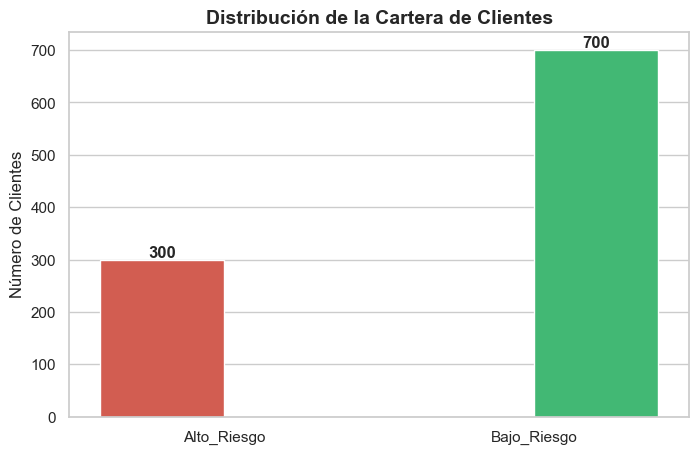

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# ¿Cuántos morosos vs buenos pagadores tenemos
resumen_riesgo = df['Riesgo'].value_counts()
print("--- CARTERA DE CLIENTES ---")
print(resumen_riesgo)
print("-" * 25)

# ¿Para qué nos piden el dinero? (Top 5 de propósitos)
print("\n--- TOP 5 PROPÓSITOS DEL PRÉSTAMO ---")
print(df['Proposito_Prestamo'].value_counts().head(5))

# Gráfico visual del desbalanceo
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Riesgo', hue='Riesgo', palette=['#e74c3c','#2ecc71'],legend=False)
plt.title('Distribución de la Cartera de Clientes', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Número de Clientes')

# Añadir los números encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.show()    


### Análisis de Negocio:
El análisis exploratorio nos revela un problema crítico: la cartera de clientes está desbalanceada con una tasa de morosidad del 30% (300 impagados frente a los 700 préstamos sanos). Además, observamos que el crédito se destina principalmente a bienes de consumo (tecnología y vehículos). Cualquier modelo de Credit Scoring que implementemos deberá ser especialmente sensible para detectar este alto porcentaje de clientes tóxicos sin paralizar la concesión de créditos.

## Mapeanndo el texto y transformándo a 0 y 1

In [4]:
# Convertimos la variable objetivo a 0 y 1
# 0 = Buen pagador (Bajo Riesgo), 1 = Moroso / Default (Alto Riesgo)
df['Riesgo'] = df['Riesgo'].map({'Bajo_Riesgo': 0, 'Alto_Riesgo': 1})



# Separamos los datos del cliente (X) de la respuesta que queremos predecir (y)
X = df.drop('Riesgo', axis=1)
y = df['Riesgo']

# Convertimos el resto de variables de texto en números (One-Hot Encoding)
X_numerico = pd.get_dummies(X, drop_first=True)

print("--- TRANSFORMACIÓN MATEMÁTICA COMPLETADA ---")
print(f"Columnas originales del cliente: {X.shape[1]}")
print(f"Nuevas columnas matemáticas creadas: {X_numerico.shape[1]}")
display(X_numerico.head(3))

--- TRANSFORMACIÓN MATEMÁTICA COMPLETADA ---
Columnas originales del cliente: 13
Nuevas columnas matemáticas creadas: 39


,Duracion_Meses,Importe_Solicitado,Ratio_Endeudamiento,Edad,Estado_Cuenta_<0,Estado_Cuenta_>=200,Estado_Cuenta_no checking,Historial_Crediticio_critical/other existing credit,Historial_Crediticio_delayed previously,Historial_Crediticio_existing paid,...,Estado_Civil_male mar/wid,Estado_Civil_male single,Activos_Inmobiliarios_no known property,Activos_Inmobiliarios_real estate,Activos_Inmobiliarios_car,Vivienda_own,Vivienda_rent,Tipo_Empleo_unemp/unskilled non res,Tipo_Empleo_unskilled resident,Tipo_Empleo_skilled
0,6,1169,4,67,True,False,False,True,False,False,...,False,True,False,True,False,True,False,False,False,True
1,48,5951,2,22,False,False,False,False,False,True,...,False,False,False,True,False,True,False,False,False,True
2,12,2096,2,49,False,False,True,True,False,False,...,False,True,False,True,False,True,False,False,True,False


### Ingeniería de Datos:
Para que el algoritmo de Machine Learning pueda procesar la información, hemos aplicado One-Hot Encoding. Esto transforma variables categóricas en una matriz puramente matemática de 39 características, listas para alimentar nuestro modelo predictivo. 

# Entrenamiento modelo Random Forest

Entrenando el algoritmo con 800 clientes...
 Examinando al algoritmo con 200 clientes...



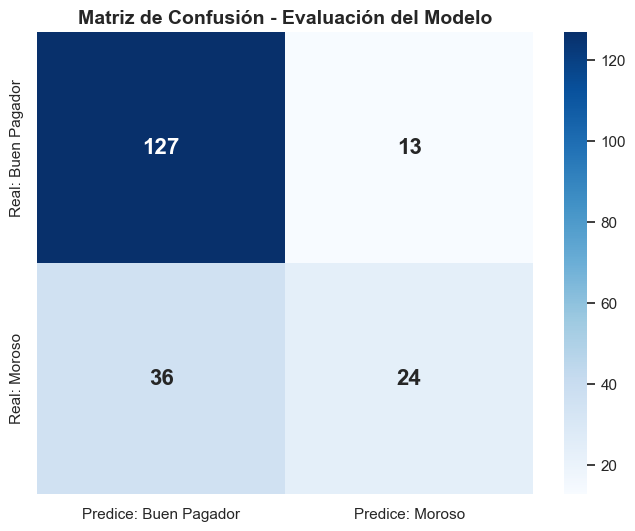


--- REPORTE DE MÉTRICAS ---
                 precision    recall  f1-score   support

Bajo Riesgo (0)       0.78      0.91      0.84       140
Alto Riesgo (1)       0.65      0.40      0.49        60

       accuracy                           0.76       200
      macro avg       0.71      0.65      0.67       200
   weighted avg       0.74      0.76      0.74       200



In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Separamos los datos (80% entrenamiento, 20% para el test/examen)
X_train, X_test, y_train, y_test = train_test_split(
    X_numerico, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenando el algoritmo con {X_train.shape[0]} clientes...")
print(f" Examinando al algoritmo con {X_test.shape[0]} clientes...\n")

# Creamos el modelo Random Forest 
# class_weight='balanced' le dice al modelo que preste especial atención a los morosos
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# El modelo estudia los datos en la fase fit
modelo_rf.fit(X_train, y_train)

# El modelo se examina
predicciones = modelo_rf.predict(X_test)

# Visualizamos la nota del examen: La Matriz de Confusión
cm = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predice: Buen Pagador', 'Predice: Moroso'],
            yticklabels=['Real: Buen Pagador', 'Real: Moroso'],
            annot_kws={"size": 16, "weight": "bold"})
plt.title('Matriz de Confusión - Evaluación del Modelo', fontsize=14, fontweight='bold')
plt.show()

# Reporte técnico
print("\n--- REPORTE DE MÉTRICAS ---")
print(classification_report(y_test, predicciones, target_names=['Bajo Riesgo (0)', 'Alto Riesgo (1)']))


### Evaluación del Modelo Base:
El modelo Random Forest inicial logra clasificar correctamente a la mayoría de los buenos pagadores. Sin embargo, desde la perspectiva de Riesgos, el modelo es demasiado permisivo: se nos escapan 36 morosos (Falsos Negativos). En el sector bancario, el coste de aprobar un préstamo a un moroso es infinitamente superior al coste de rechazar por error a un buen cliente. Necesitamos ajustar el umbral de decisión.


## Ajuste del Umbral

como se trata de préstamos bancarios, tenemos que ajustar a que se intercepte como moroso a todo aquel que tenga un riesgo del 30% de impago.

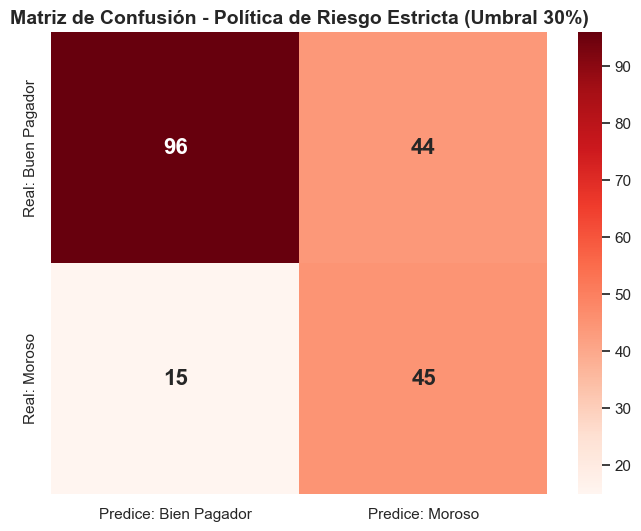


--- NUEVO REPORTE DE MÉTRICAS (UMBRAL 30%) ---
                 precision    recall  f1-score   support

Bajo Riesgo (0)       0.86      0.69      0.76       140
Alto Riesgo (1)       0.51      0.75      0.60        60

       accuracy                           0.70       200
      macro avg       0.69      0.72      0.68       200
   weighted avg       0.76      0.70      0.72       200



In [6]:
import numpy as np

# En lugar de pedirle al modelo la decisión final, le pedimos la probabilidad matemática pura
probabilidades_riesgo = modelo_rf.predict_proba(X_test)[:, 1]

# CREAMOS UNA POLÍTICA DE RIESGO ESTRICTAA
# Marca a todo aquel que tenga un 30% de riesgo de impago, lo marcamos como Moroso (1)
umbral_estricto = 0.30
predicciones_estrictas = np.where(probabilidades_riesgo >= umbral_estricto, 1, 0)

# Volvemos a evaluar al modelo con nuestra nueva politica
cm_estricta = confusion_matrix(y_test, predicciones_estrictas)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_estricta, annot=True, fmt='d', cmap='Reds',  # Lo ponemos en rojo porque estamos en modo alerta
            xticklabels=['Predice: Bien Pagador', 'Predice: Moroso'],
            yticklabels=['Real: Buen Pagador', 'Real: Moroso'],
            annot_kws={"size": 16, "weight": "bold"})
plt.title('Matriz de Confusión - Política de Riesgo Estricta (Umbral 30%)', fontsize=14, fontweight='bold')
plt.show()

# Comprobamos el impacto
print("\n--- NUEVO REPORTE DE MÉTRICAS (UMBRAL 30%) ---")
print(classification_report(y_test, predicciones_estrictas, target_names=['Bajo Riesgo (0)', 'Alto Riesgo (1)']))


### Ajuste de Políticas de Riesgo (Threshold Tuning):
Hemos intervenido las probabilidades matemáticas del algoritmo, obligándole a denegar el préstamo si detecta más de un 30% de riesgo de impago.

- Impacto positivo: Reducimos drásticamente los impagos que entran al banco (de 36 pasamos a 15).
- Trade-off: Como efecto secundario, nos volvemos más conservadores y rechazamos a 44 clientes buenos (Falsos Positivos).

Esta configuración es ideal para escenarios macroeconómicos de recesión donde la prioridad absoluta del banco es proteger el capital frente al crecimiento comercial.

# Explicabilidad del modelo

C:\Users\jorge\AppData\Local\Temp\ipykernel_17952\1540230858.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='mako')


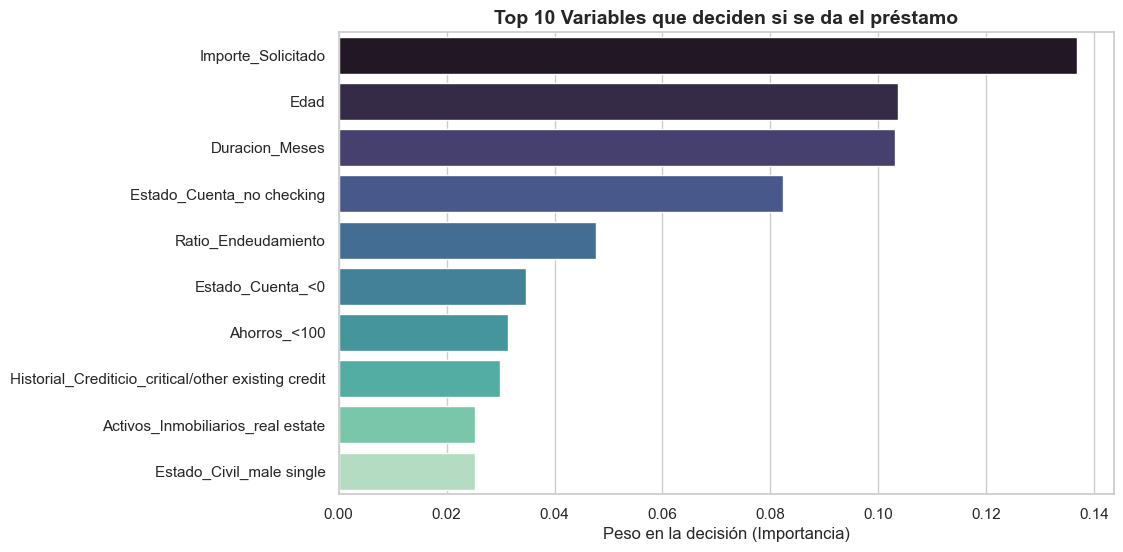

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos el "peso" que el modelo le ha dado a cada variable
importancias = modelo_rf.feature_importances_
columnas = X_numerico.columns

# Creamos una tabla y la ordenamos de mayor a menor importancia
df_importancias = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False).head(10) # Cogemos el Top 10

# Visualización del gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='mako')
plt.title('Top 10 Variables que deciden si se da el préstamo', fontsize=14, fontweight='bold')
plt.xlabel('Peso en la decisión (Importancia)')
plt.ylabel('')
plt.show()


### Explicabilidad del Modelo (Feature Importance):
El algoritmo ha aprendido de forma autónoma las reglas fundamentales del riesgo financiero. Las tres variables que más pesan en la decisión de conceder el crédito son:
1. Importe Solicitado: La magnitud de la exposición al riesgo.
2. Edad: Factor fuertemente correlacionado con la estabilidad laboral e ingresos.
3. Duración del préstamo: A mayor plazo, mayor probabilidad de que el cliente sufra imprevistos económicos.